In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys

folder_path = "knee_angles_csv/"
output_folder_path = "knee_angles_plots/"

for ath in sorted(os.listdir(folder_path)):
    # ath = "ATH02"
    for session in sorted(os.listdir(os.path.join(folder_path, ath))):
        # session = "s2"
        session_folder_path = os.path.join(folder_path, ath, session)
        print(f'Processing {ath} {session}...')
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'Mid Hip Y Coordinate Over Frames for {ath} {session}')
        axes = axes.flatten()
        i = 0
        for csv_file in sorted(os.listdir(session_folder_path)):
            window = 30
            csv_path = os.path.join(session_folder_path, csv_file)
            df = pd.read_csv(csv_path)
            mid_hip_y_list = df['mid_hip_y']
            mid_hip_y_list = pd.DataFrame(mid_hip_y_list).interpolate().bfill().values.ravel().tolist()
            left_abduction_angle_list = df['left_abduction_angle']
            left_abduction_angle_list = pd.DataFrame(left_abduction_angle_list).interpolate().bfill().values.ravel().tolist()
            mid_hip_y_derivative = np.diff(mid_hip_y_list)
            max_derivative_idx = np.argmax(mid_hip_y_derivative)
            if max_derivative_idx < window or max_derivative_idx > len(mid_hip_y_derivative) - window:
                window = min(max_derivative_idx, len(mid_hip_y_derivative) - max_derivative_idx)
            mid_hip_max = np.argmax(mid_hip_y_list[max_derivative_idx-window:max_derivative_idx+window])
            mid_hip_max_idx = max_derivative_idx - window + mid_hip_max

            # Plot the abduction angle only in a window around the mid_hip_max frame
            plot_window = 50
            start_idx = max(0, mid_hip_max_idx - plot_window)
            end_idx = min(len(left_abduction_angle_list), mid_hip_max_idx + plot_window)
            axes[i].plot(left_abduction_angle_list[start_idx:end_idx], label='Left Abduction Angle')
            # Put a line in the middle of the plot to indicate the landing
            axes[i].axvline(x=plot_window, color='r', linestyle='--', label='Landing Frame')
            axes[i].set_title(f'{csv_file}')
            axes[i].set_xlabel('Frame')
            axes[i].set_xticks(range(0, end_idx - start_idx, 15))
            axes[i].set_xticklabels(range(start_idx, end_idx, 15))
            axes[i].set_ylabel('Angle (degrees)')
            axes[i].legend()
            i += 1
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        output_path = os.path.join(output_folder_path, ath + f'/{session}_abduction_angle_plot.png')
        # plt.show()
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path)
        plt.close()


Processing ATH01 s1...
Processing ATH01 s2...
Processing ATH02 s1...
Processing ATH02 s2...
Processing ATH03 s1...
Processing ATH03 s2...
Processing ATH04 s1...
Processing ATH04 s2...
Processing ATH05 s1...
Processing ATH05 s2...
Processing ATH06 s1...
Processing ATH06 s2...
Processing ATH07 s1...
Processing ATH07 s2...
Processing ATH08 s1...
Processing ATH08 s2...
Processing ATH09 s1...
Processing ATH09 s2...
Processing ATH10 s1...
Processing ATH10 s2...
Processing ATH11 s1...
Processing ATH11 s2...
Processing ATH12 s1...
Processing ATH12 s2...
Processing ATH13 s1...
Processing ATH13 s2...
Processing ATH14 s1...
Processing ATH14 s2...
Processing ATH15 s1...
Processing ATH15 s2...
Processing ATH16 s1...
Processing ATH16 s2...
Processing ATH17 s1...
Processing ATH17 s2...
Processing ATH18 s1...
Processing ATH18 s2...
Processing ATH19 s1...
Processing ATH19 s2...
Processing ATH21 s2...
Processing ATH22 s1...
Processing ATH22 s2...
Processing ATH23 s1...
Processing ATH23 s2...
Processing 

In [8]:
mid_hip_max_idx

np.int64(501)

# -----------------------------------------------------------------------

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys

folder_path = "knee_angles_csv/"
output_folder_path = "knee_angles_plots/"


ath = "ATH02"
session = "s2"
session_folder_path = os.path.join(folder_path, ath, session)
print(f'Processing {ath} {session}...')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Mid Hip Y Coordinate Over Frames for {ath} {session}')
axes = axes.flatten()
i = 0
for csv_file in sorted(os.listdir(session_folder_path)):
    window = 30
    csv_path = os.path.join(session_folder_path, csv_file)
    df = pd.read_csv(csv_path)
    mid_hip_y_list = df['mid_hip_y']
    mid_hip_y_list = pd.DataFrame(mid_hip_y_list).interpolate().bfill().values.ravel().tolist()
    left_abduction_angle_list = df['left_abduction_angle']
    left_abduction_angle_list = pd.DataFrame(left_abduction_angle_list).interpolate().bfill().values.ravel().tolist()
    mid_hip_y_derivative = np.diff(mid_hip_y_list)
    max_derivative_idx = np.argmax(mid_hip_y_derivative)
    if max_derivative_idx < window or max_derivative_idx > len(mid_hip_y_derivative) - window:
        window = min(max_derivative_idx, len(mid_hip_y_derivative) - max_derivative_idx)
    mid_hip_max = np.argmax(mid_hip_y_list[max_derivative_idx-window:max_derivative_idx+window])

    # Plot the abduction angle only in a window around the mid_hip_max frame
    plot_window = 50
    start_idx = max(0, mid_hip_max - plot_window)
    end_idx = min(len(left_abduction_angle_list), mid_hip_max + plot_window)
    axes[i].plot(left_abduction_angle_list[start_idx:end_idx], label='Left Abduction Angle')
    # Put a line in the middle of the plot to indicate the landing
    axes[i].axvline(x=plot_window, color='r', linestyle='--', label='Landing Frame')
    axes[i].set_title(f'{csv_file}')
    axes[i].set_xlabel('Frame')
    axes[i].set_ylabel('Angle (degrees)')
    axes[i].legend()
    i += 1
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
output_path = os.path.join(output_folder_path, ath + f'/{session}_abduction_angle_plot.png')
# plt.show()
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(output_path)
plt.close()


Processing ATH02 s2...


Processing ATH01 s1 Pre Cut.2103582.20240108151333_annoted.mp4...
Finished processing in 39.49 seconds.


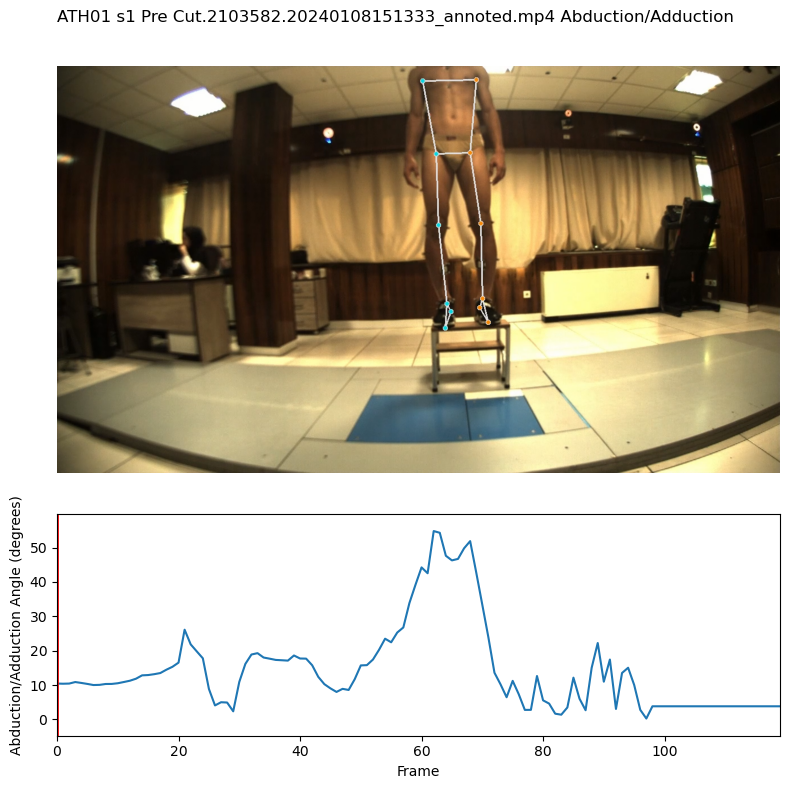

In [ ]:
# Synchronized video (top) + knee-angle plot (bottom) animation
import cv2, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import pandas as pd

folder_path = 'ATH_videos_avi_processed/'
output_folder_path  = 'landing_animations/'
csv_folder_path = 'knee_angles_csv/'

for ath in sorted(os.listdir(folder_path)):
    for session in sorted(os.listdir(os.path.join(folder_path, ath))):
        for video in sorted(os.listdir(os.path.join(folder_path, ath, session))):
            print(f'Processing {ath} {session} {video}...')
            start_time = time.time()
            video_path = os.path.join(folder_path, ath, session, video)
            cap = cv2.VideoCapture(video_path)
            fps = cap.get(cv2.CAP_PROP_FPS) or 30
            frames = []
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            cap.release()

            window = 30
            csv_path = os.path.join(csv_folder_path, ath, session, video.replace('_annoted.mp4', '_angles.csv'))
            df = pd.read_csv(csv_path)
            mid_hip_y_list = df['mid_hip_y']
            mid_hip_y_list = pd.DataFrame(mid_hip_y_list).interpolate().bfill().values.ravel().tolist()
            left_abduction_angle_list = df['left_abduction_angle']
            left_abduction_angle_list = pd.DataFrame(left_abduction_angle_list).interpolate().bfill().values.ravel().tolist()
            mid_hip_y_derivative = np.diff(mid_hip_y_list)
            max_derivative_idx = np.argmax(mid_hip_y_derivative)
            if max_derivative_idx < window or max_derivative_idx > len(mid_hip_y_derivative) - window:
                print('test')
                window = min(max_derivative_idx, len(mid_hip_y_derivative) - max_derivative_idx)
            mid_hip_max = np.argmax(mid_hip_y_list[max_derivative_idx-window:max_derivative_idx+window])
            mid_hip_max_idx = max_derivative_idx - window + mid_hip_max

            plot_window = 60
            start_idx = max(0, mid_hip_max_idx - plot_window)
            end_idx = min(len(left_abduction_angle_list), mid_hip_max_idx + plot_window)

            # Ensure `angle_list` exists (computed earlier) and synchronize lengths
            try:
                n_frames = min(len(frames), len(left_abduction_angle_list[start_idx:end_idx]))
            except NameError:
                raise NameError('left_abduction_angle_list not found.')
            if n_frames == 0:
                raise RuntimeError('No frames or abduction/adduction angles available to animate.')
            frames = frames[start_idx:end_idx]
            angles = np.array(left_abduction_angle_list[start_idx:end_idx][:n_frames])


            # Create figure with video on top and plot below
            fig = plt.figure(figsize=(8,8))
            fig.suptitle(f'{ath} {session} {video} Abduction/Adduction')
            ax_vid = plt.subplot2grid((3,1),(0,0), rowspan=2)
            ax_plot = plt.subplot2grid((3,1),(2,0))
            im = ax_vid.imshow(frames[0])
            ax_vid.axis('off')
            # Plot full angle trace and set up vertical frame indicator
            ax_plot.plot(np.arange(n_frames), angles, color='C0')
            vline = ax_plot.axvline(0, color='r', linewidth=2)
            ax_plot.set_xlim(0, n_frames-1)
            pad = max(5, (angles.max()-angles.min())*0.05)
            ax_plot.set_ylim(angles.min()-pad, angles.max()+pad)
            ax_plot.set_xlabel('Frame')
            ax_plot.set_ylabel('Abduction/Adduction Angle (degrees)')
            plt.tight_layout()

            # Update function: swap video frame and move vertical line
            def update(i, frames, im, vline):
                im.set_data(frames[i])
                vline.set_xdata([i,i])
                return im, vline

            interval = 1000.0 / (fps if fps>0 else 30)
            ani = animation.FuncAnimation(fig, update, frames=n_frames, fargs=(frames, im, vline), blit=False, interval=interval)
            save_path = os.path.join(output_folder_path, ath, session, video.replace('_annoted.mp4', '_abduction_adduction.mp4'))
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            ani.save(save_path, writer='ffmpeg')
            end_time = time.time()
            print(f'Finished processing in {end_time - start_time:.2f} seconds.')

In [20]:
len(frames), len(left_abduction_angle_list), start_idx, end_idx, max_derivative_idx, mid_hip_max

(919, 919, np.int64(7), np.int64(87), np.int64(807), np.int64(47))

In [21]:
len(mid_hip_y_derivative) - max_derivative_idx

np.int64(111)

In [22]:
len(mid_hip_y_derivative)

918